# Imports

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Diffusion Schedule

In [2]:
T = 1000

beta = torch.linspace(1e-4, 0.02, T)
alpha = 1 - beta
alpha_cumprod = torch.cumprod(alpha, dim=0)

sqrt_acp = torch.sqrt(alpha_cumprod)
sqrt_omacp = torch.sqrt(1 - alpha_cumprod)

# Unet Architecture

In [3]:
class UNet2ch(nn.Module):

    def __init__(self, base_ch=64):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(2, base_ch)
        self.enc2 = conv_block(base_ch, base_ch*2)
        self.enc3 = conv_block(base_ch*2, base_ch*4)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(base_ch*4, base_ch*8)

        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, 2, stride=2)
        self.dec3 = conv_block(base_ch*8, base_ch*4)

        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = conv_block(base_ch*4, base_ch*2)

        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = conv_block(base_ch*2, base_ch)

        self.final = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)

# DDPM Model

In [4]:
class DDPMx0_2ch(nn.Module):
    def __init__(self, k=4):
        super().__init__()

        self.unet = UNet2ch()
        self.k = k

        # These are registered as buffers so they move to GPU with .to(device)
        self.register_buffer("beta", beta)
        self.register_buffer("alpha", alpha)
        self.register_buffer("alpha_cumprod", alpha_cumprod)
        self.register_buffer("sqrt_acp", sqrt_acp)
        self.register_buffer("sqrt_omacp", sqrt_omacp)

    def q_sample(self, x0, t, noise):
        # Extract constants for the specific timesteps in the batch
        return (
            self.sqrt_acp[t].view(-1,1,1,1) * x0
            + self.sqrt_omacp[t].view(-1,1,1,1) * noise
        )

    def forward(self, x0):
        B, _, H, W = x0.shape

        # -------- L0 term (x1 -> x0) --------
        t1 = torch.ones(B, device=x0.device, dtype=torch.long)
        noise = torch.randn_like(x0)
        x1 = self.q_sample(x0, t1, noise)

        # FIX: Normalize t by dividing by total timesteps T
        t1_norm = (t1.float() / T).view(-1,1,1,1).expand(-1,1,H,W)
        inp_l0 = torch.cat([x1, t1_norm], dim=1)

        x0_hat_l0 = self.unet(inp_l0)
        loss_L0 = F.mse_loss(x0_hat_l0, x0)

        # -------- diffusion loss --------
        loss_diff = 0
        for _ in range(self.k):
            # Sample random timesteps from 2 to T-1
            t = torch.randint(2, T, (B,), device=x0.device)

            noise = torch.randn_like(x0)
            x_t = self.q_sample(x0, t, noise)

            # FIX: Normalize t by dividing by total timesteps T
            t_norm = (t.float() / T).view(-1,1,1,1).expand(-1,1,H,W)
            inp_t = torch.cat([x_t, t_norm], dim=1)

            x0_hat_t = self.unet(inp_t)
            loss_diff += F.mse_loss(x0_hat_t, x0)

        loss_diff = loss_diff / self.k

        return loss_L0 + loss_diff

# Sampling Inference

In [5]:
@torch.no_grad()
def sample(model, shape, device):
    model.eval()
    x = torch.randn(shape, device=device)
    B, _, H, W = shape

    # We loop from T-1 down to 1
    for i in reversed(range(1, T)):
        t = torch.full((B,), i, device=device, dtype=torch.long)

        # 1. Normalize T to match the training fix!
        t_norm = (t.float() / T).view(-1,1,1,1).expand(-1,1,H,W)
        inp = torch.cat([x, t_norm], dim=1)

        # 2. Predict the clean image x0
        x0_hat = model.unet(inp)

        # 3. Get constants for this specific timestep
        alpha_t = model.alpha[i]
        alpha_t_cum = model.alpha_cumprod[i]
        alpha_t_prev = model.alpha_cumprod[i-1]

        # 4. THE MATH FIX: Calculate posterior mean
        # This formula is derived from q(x_{t-1} | x_t, x_0)
        coeff_x0 = (torch.sqrt(alpha_t_prev) * model.beta[i]) / (1 - alpha_t_cum)
        coeff_xt = (torch.sqrt(alpha_t) * (1 - alpha_t_prev)) / (1 - alpha_t_cum)

        mean = coeff_x0 * x0_hat + coeff_xt * x

        # 5. Add noise for all steps except the very last one
        if i > 1:
            # You can use beta_t or the posterior variance. Beta_t is standard.
            sigma = torch.sqrt(model.beta[i])
            noise = torch.randn_like(x)
            x = mean + sigma * noise
        else:
            x = mean

    # If you used transforms.Normalize((0.5,), (0.5,)) in training,
    # use (x + 1) / 2 here. If you stayed with [0, 1], use clamp.
    return x.clamp(0, 1)

# Training MNIST Setup

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loader = DataLoader(
    datasets.MNIST(
        "./data",
        train=True,
        download=True,
        transform=transforms.Compose([
            transforms.Resize((32,32)),
            transforms.ToTensor()
        ])
    ),
    batch_size=128,
    shuffle=True,
    num_workers=2
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


# Training

In [7]:
model = DDPMx0_2ch(k=4).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20
losses = []

for ep in range(epochs):

    model.train()
    total = 0

    pbar = tqdm(loader, desc=f"Epoch {ep+1}/{epochs}")

    for x,_ in pbar:

        x = x.to(device)

        loss = model(x)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

        pbar.set_postfix(loss=loss.item())

    avg = total / len(loader)

    print(f"Epoch {ep+1}/{epochs} Avg Loss {avg:.4f}")

    losses.append(avg)

Epoch 1/20: 100%|██████████| 469/469 [03:37<00:00,  2.16it/s, loss=0.0392]


Epoch 1/20 Avg Loss 0.0516


Epoch 2/20: 100%|██████████| 469/469 [03:43<00:00,  2.10it/s, loss=0.0417]


Epoch 2/20 Avg Loss 0.0403


Epoch 3/20: 100%|██████████| 469/469 [03:43<00:00,  2.10it/s, loss=0.0402]


...

Epoch 18/20 Avg Loss 0.0362


Epoch 19/20: 100%|██████████| 469/469 [03:40<00:00,  2.13it/s, loss=0.0399]


Epoch 19/20 Avg Loss 0.0363


Epoch 20/20: 100%|██████████| 469/469 [03:39<00:00,  2.14it/s, loss=0.0348]

Epoch 20/20 Avg Loss 0.0362


# Plotting Loss

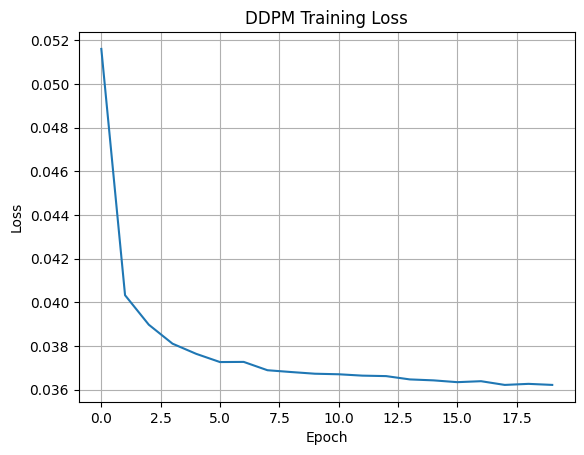

In [8]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DDPM Training Loss")
plt.grid()
plt.show()

# Generate Samples

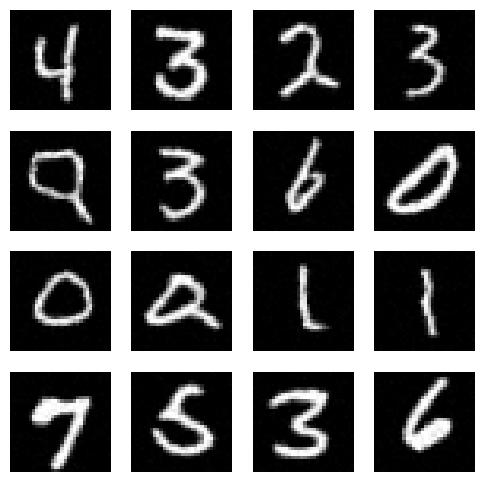

In [9]:
model.eval()

samples = sample(model,(16,1,32,32),device).cpu()

fig,axs = plt.subplots(4,4,figsize=(6,6))

for i,ax in enumerate(axs.flatten()):
    ax.imshow(samples[i,0],cmap="gray")
    ax.axis("off")

plt.show()